# CNN Fruit Classification

## Extract Dataset

In [9]:
import os
import zipfile

zip_file_path = 'FruitinAmazon.zip'
if os.path.exists(zip_file_path):

    if not os.path.exists('train'):
        print(f"Unzipping {zip_file_path}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Unzipping complete.")
    else:
        print("Train directory already exists, skipping unzipping.")
else:
    print(f"Warning: {zip_file_path} not found. Ensure the dataset is uploaded.")

train_dir = None

for root, dirs, files in os.walk("."):
    if os.path.basename(root).lower() == "train":
        train_dir = root
        break

print("Detected train directory:", train_dir)

if train_dir is None:
    raise Exception("Train folder not found!")

Unzipping FruitinAmazon.zip...
Unzipping complete.
Detected train directory: ./FruitinAmazon/train


## Task 1: Visualization

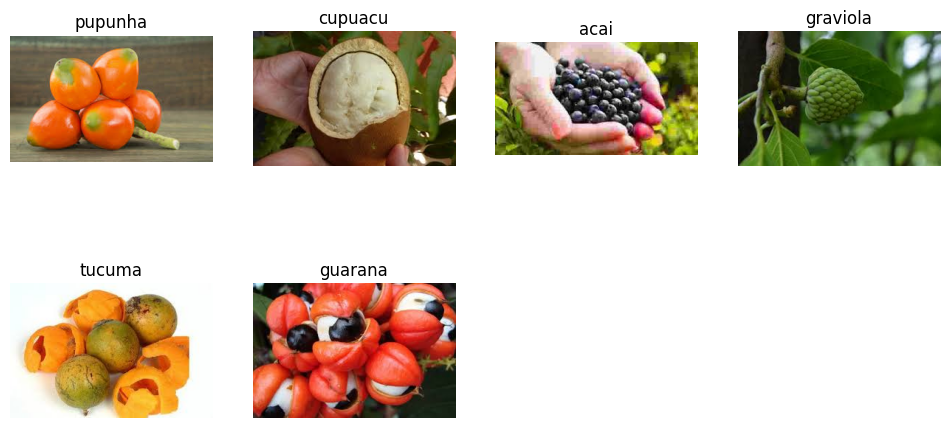

In [10]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

images, labels = [], []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img)

    images.append(Image.open(img_path))
    labels.append(cls)

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")
plt.show()

Check for corrupted images



In [20]:
from PIL import Image

corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print("Removed corrupted image:", img_path)
                corrupted.append(img_path)
                os.remove(img_path)

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


## Task 2: Load Data

In [21]:
import tensorflow as tf

img_height, img_width = 128,128
batch_size = 32

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Get class names before mapping
class_names = train_ds.class_names

train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

print(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## Task 3: CNN Model

In [22]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(len(class_names),activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [23]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=10,restore_best_weights=True)

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=50,
                    callbacks=[early])

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 839ms/step - accuracy: 0.1389 - loss: 2.4859 - val_accuracy: 0.1111 - val_loss: 1.9689
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 0.1806 - loss: 2.0475 - val_accuracy: 0.1667 - val_loss: 1.7652
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step - accuracy: 0.2500 - loss: 1.7329 - val_accuracy: 0.3333 - val_loss: 1.7568
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.3889 - loss: 1.6758 - val_accuracy: 0.0556 - val_loss: 1.8028
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.2500 - loss: 1.6177 - val_accuracy: 0.0556 - val_loss: 1.8251
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.4167 - loss: 1.4452 - val_accuracy: 0.2222 - val_loss: 1.8068
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 442ms/step - accuracy: 0.6389 - loss: 1.1969 - val_accuracy: 0.3889 - val_loss: 1.6657
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.7500 - loss: 0.9028 - val_accuracy: 0.1667 - val_loss:

## Graphs

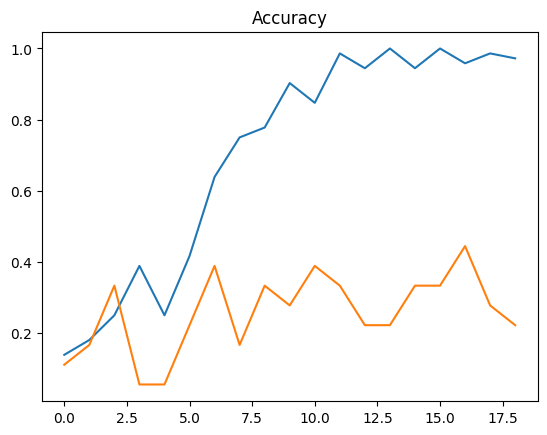

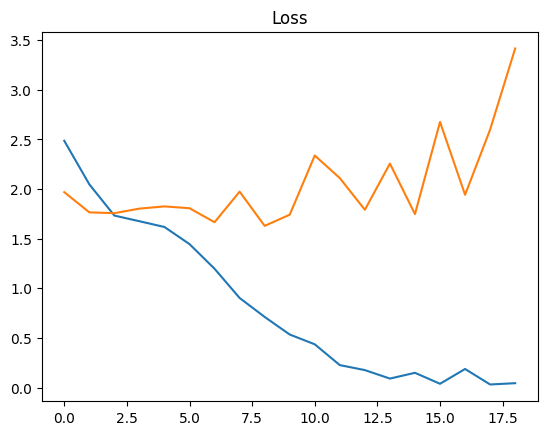

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.show()

## Evaluate

In [26]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3333 - loss: 1.6289


[1.6289068460464478, 0.3333333432674408]

## Save & Load

In [18]:
model.save("fruit_model.h5")

from tensorflow.keras.models import load_model
m = load_model("fruit_model.h5")
m.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.3333 - loss: 1.7020


[1.70203697681427, 0.3333333432674408]

Predictions and Classification Report

In [27]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         3
           3       0.67      0.40      0.50         5
           4       0.00      0.00      0.00         4
           5       0.23      1.00      0.38         3

    accuracy                           0.33        18
   macro avg       0.32      0.40      0.31        18
weighted avg       0.28      0.33      0.26        18

